In [1]:
import plotly.offline as pyo
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

init_notebook_mode(connected=True)

In [2]:
import cufflinks as cf
cf.go_offline()

In [3]:
import matplotlib.pyplot as plt

In [4]:
from plotly.subplots import make_subplots  # import funkcji do tworzenia wykresów w układzie subplotów

In [5]:
import pandas as pd
miedz = pd.read_csv('ca_c_f_d.csv')
miedz.head()

,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie
0,2015-01-02,6309.0,6309.0,6309.0,6309.0
1,2015-01-05,6216.0,6216.0,6216.0,6216.0
2,2015-01-06,6191.0,6191.0,6191.0,6191.0
3,2015-01-07,6170.0,6170.0,6170.0,6170.0
4,2015-01-08,6230.5,6230.5,6230.5,6230.5


In [6]:
kghm = pd.read_csv('kgh_d.csv')
kghm.head()

,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen
0,2015-01-02,102.45,102.83,101.97,102.40,309987
1,2015-01-05,102.16,102.88,99.91,100.09,479228
2,2015-01-07,100.53,105.45,99.67,104.89,966372
3,2015-01-08,105.35,107.15,105.35,107.11,711805
4,2015-01-09,107.15,107.15,103.87,104.33,563221


In [7]:
# Konwersja kolumny Data do formatu daty

miedz['Data'] = pd.to_datetime(miedz['Data'], errors='coerce')
kghm['Data'] = pd.to_datetime(kghm['Data'], errors='coerce')

In [8]:
#połączenie tabel

tabela = pd.merge(
    kghm[['Data','Zamkniecie']],
    miedz[['Data','Zamkniecie']],
    on='Data',
)

#zmiana nazw kolumn
tabela.columns = ['Data', 'KGHM', 'Miedź']

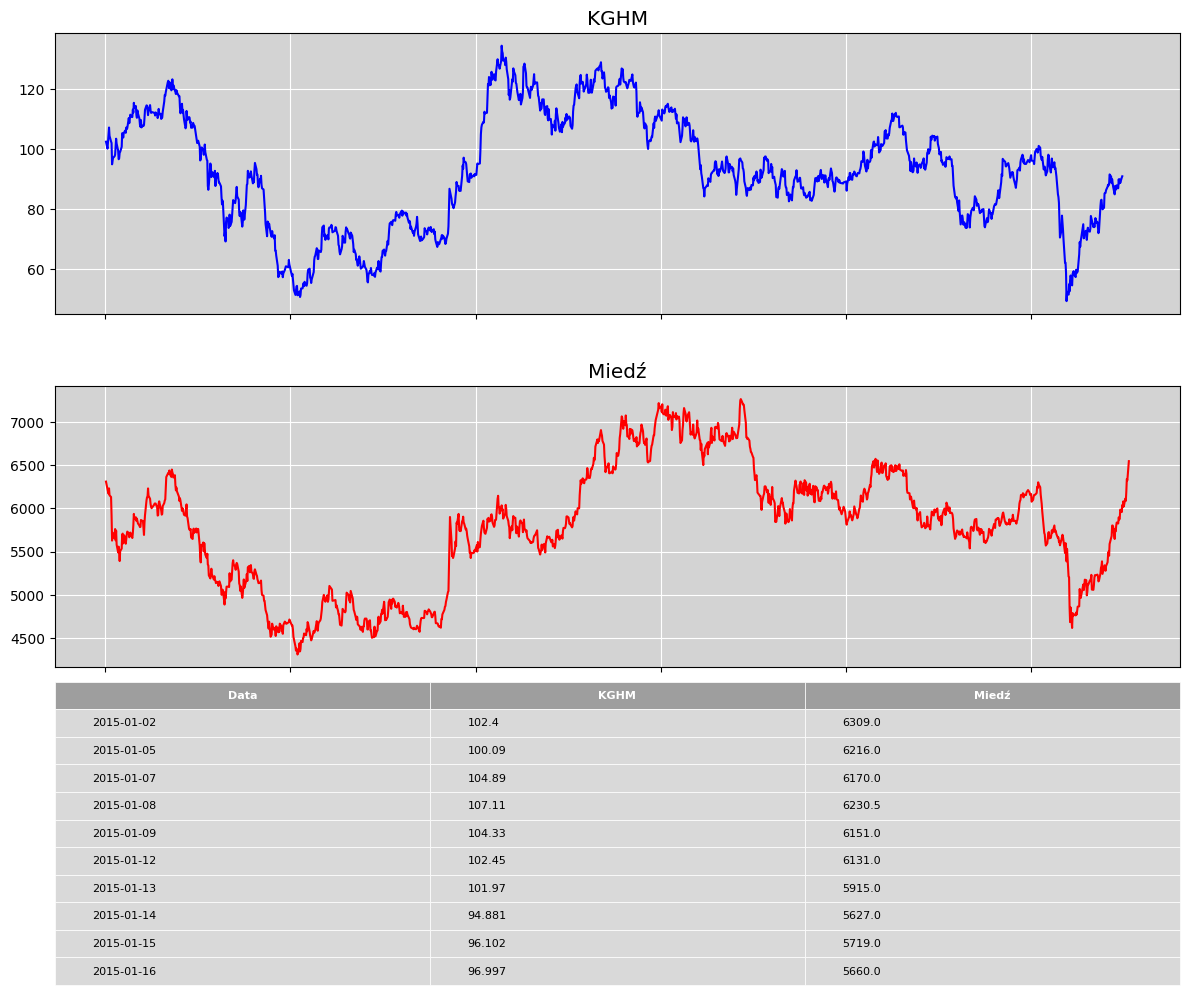

In [9]:
# Tworzenie wykresów
# 3 elementy: 2 wykresy + tabela
fig, axes = plt.subplots(
    3, 1,
    figsize=(12, 10),
    sharex=True,   # osie X sa zalezne
    gridspec_kw={'height_ratios': [3, 3, 2]}
)

# Styl wykresu
plt.style.use('ggplot')

# KGHM
axes[0].plot(kghm['Data'], kghm['Zamkniecie'],color='blue')
axes[0].set_title('KGHM')
axes[0].set_facecolor('#d3d3d3')   # szare tło
axes[0].grid(color='white')        # białe linie siatki

# Miedź
axes[1].plot(miedz['Data'], miedz['Zamkniecie'], color='red')
axes[1].set_title('Miedź')
axes[1].set_facecolor('#d3d3d3')   # szare tło
axes[1].grid(color='white')        # białe linie siatki

# Tabela
axes[2].axis('off')
axes[2].set_facecolor('#d3d3d3')

# przygotowanie danych do tabeli
table_data = tabela.head(10).copy()

# zamiana daty
table_data['Data'] = pd.to_datetime(table_data['Data']).dt.strftime('%Y-%m-%d')

table = axes[2].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc='center'
)

# Styl tabeli
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)


# Szare tło komórek tabeli
for (row, col), cell in table.get_celld().items():
    
    # HEADER
    if row == 0:
        cell.set_facecolor('#9e9e9e')  # ciemniejszy szary
        cell.set_text_props(color='white', weight='bold')
    
    # DANE
    else:
        cell.set_facecolor('#d9d9d9')  # jaśniejszy szary
        cell.set_text_props(ha='left')  # 👈 wyrównanie do lewej
    
    cell.set_edgecolor('white')

plt.tight_layout()
plt.show()